TITANIC SURVIVAL PREDICTION MODEL

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [183]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [184]:
df.columns
df.shape
df.isnull().sum()



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [185]:
df.drop_duplicates(inplace=True)
df.shape

(891, 12)

In [186]:
df.replace({'Sex': {'male': 0, 'female': 1}}, inplace=True)
df.replace({'Embarked': {'S': 0, 'C': 1, 'Q': 2}}, inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\Bhawna\AppData\Local\Temp\ipykernel_18804\3677941516.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Sex': {'male': 0, 'female': 1}}, inplace=True)
C:\Users\Bhawna\AppData\Local\Temp\ipykernel_18804\3677941516.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Embarked': {'S': 0, 'C': 1, 'Q': 2}}, inplace=True)
C:\Users\Bhawna\AppData\Local\Temp\ipykernel_18804\3677941516.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an i

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

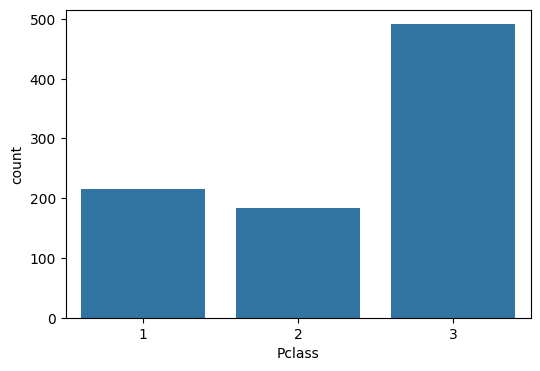

In [187]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)
df.isnull().sum()

In [188]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin','Fare'], axis=1, inplace=True)

In [189]:

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.columns
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Embarked      0
FamilySize    0
dtype: int64

Model Training

In [190]:
X = df.drop(['Survived'], axis=1)
Y = df['Survived']
X_train , X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, Y_train)
pred = model.predict(X_test_scaled)

accuracy = accuracy_score(Y_test, pred)
conf_matrix = confusion_matrix(Y_test, pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_report(Y_test, pred))


Accuracy: 0.8100558659217877
Confusion Matrix:
[[86 19]
 [15 59]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       105
           1       0.76      0.80      0.78        74

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.81      0.81      0.81       179

